# Employee Turnover Analytics
**Portobello Tech – HR Department ML Project**

This notebook covers:
1. Data Quality Checks
2. Exploratory Data Analysis (EDA)
3. K-Means Clustering of Employees Who Left
4. Class Imbalance Handling with SMOTE
5. 5-Fold Cross-Validation Model Training & Evaluation
6. Best Model Identification (ROC/AUC & Confusion Matrix)
7. Retention Strategies for Targeted Employees

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

%matplotlib inline
sns.set_theme(style='whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Load Data & Data Quality Checks

In [2]:
df = pd.read_csv('HR_comma_sep.csv')
print('Shape:', df.shape)
df.head()

Shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print('\nTotal missing values:', missing.sum())
print('\n=== Descriptive Statistics ===')
df.describe()

=== Data Types ===
satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
sales                        str
salary                       str
dtype: object

=== Missing Values ===
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

Total missing values: 0

=== Descriptive Statistics ===


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


**Observation:** There are no missing values in the dataset. All columns are complete and ready for analysis.

## 2. Exploratory Data Analysis (EDA)

### 2.1 Correlation Heatmap

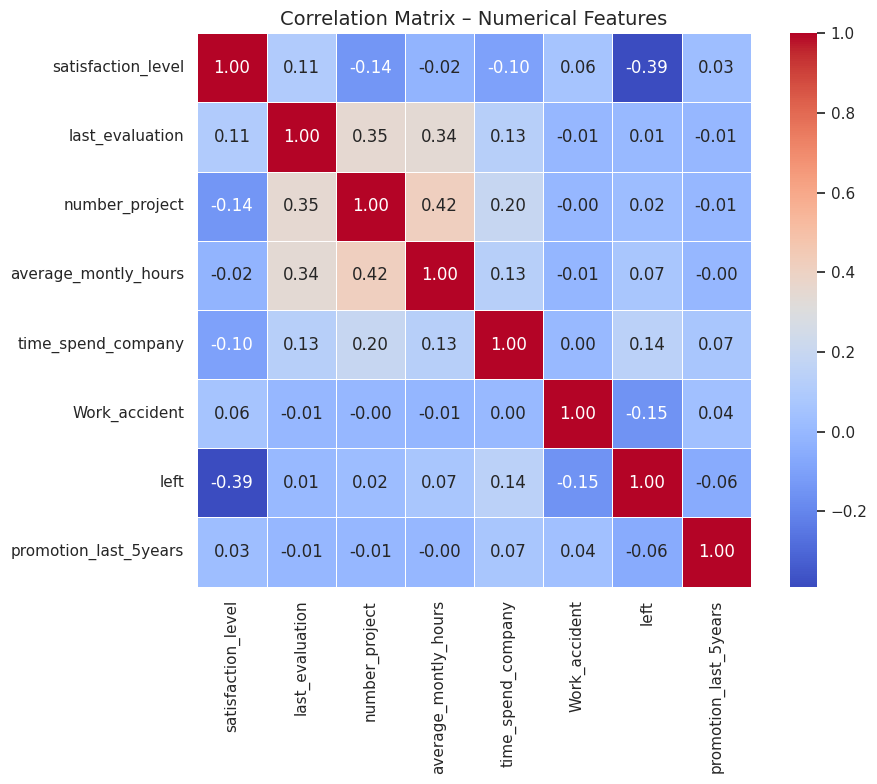

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix – Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

**Inferences from the Correlation Heatmap:**
- `number_project` and `average_montly_hours` show a moderate positive correlation (~0.42), indicating that employees with more projects also work more hours.
- `satisfaction_level` has a noticeable negative correlation with `left` (~-0.39), confirming that lower satisfaction leads to higher turnover.
- `time_spend_company` has a weak positive correlation with `left`, suggesting longer-tenured employees may also leave under certain conditions.
- `last_evaluation` and `number_project` are also moderately correlated (~0.35), showing that high-performers tend to take on more projects.

### 2.2 Distribution Plots

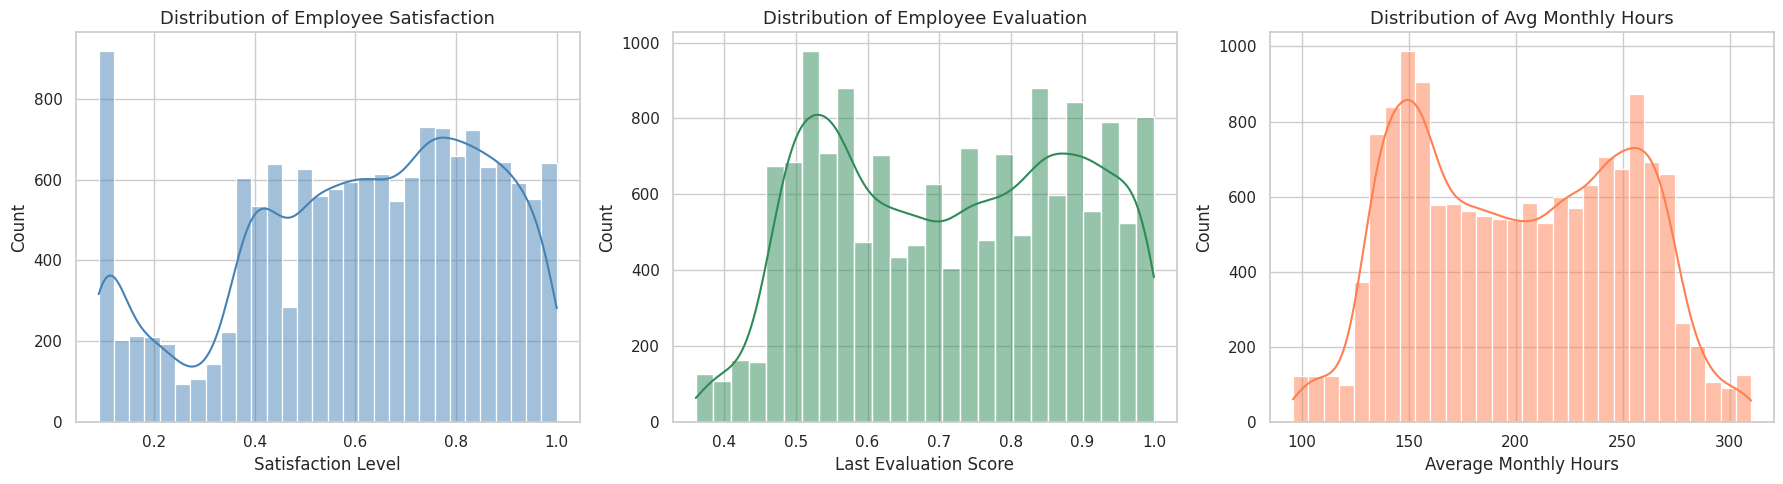

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Employee Satisfaction
sns.histplot(df['satisfaction_level'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Employee Satisfaction', fontsize=13)
axes[0].set_xlabel('Satisfaction Level')
axes[0].set_ylabel('Count')

# Employee Evaluation
sns.histplot(df['last_evaluation'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribution of Employee Evaluation', fontsize=13)
axes[1].set_xlabel('Last Evaluation Score')
axes[1].set_ylabel('Count')

# Employee Average Monthly Hours
sns.histplot(df['average_montly_hours'], kde=True, ax=axes[2], color='coral')
axes[2].set_title('Distribution of Avg Monthly Hours', fontsize=13)
axes[2].set_xlabel('Average Monthly Hours')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Inferences:**
- **Satisfaction Level** is bimodal – one group clusters around 0.1 (very dissatisfied) and a larger group around 0.6–0.8 (moderately to highly satisfied).
- **Last Evaluation** shows a fairly uniform distribution with a slight concentration at higher scores (0.7–0.9), suggesting the company tends to retain high performers.
- **Average Monthly Hours** is bimodal as well – peaks around 150 hrs and 250 hrs/month, suggesting two distinct work-style groups (normal and overworked employees).

### 2.3 Employee Project Count – Left vs. Stayed

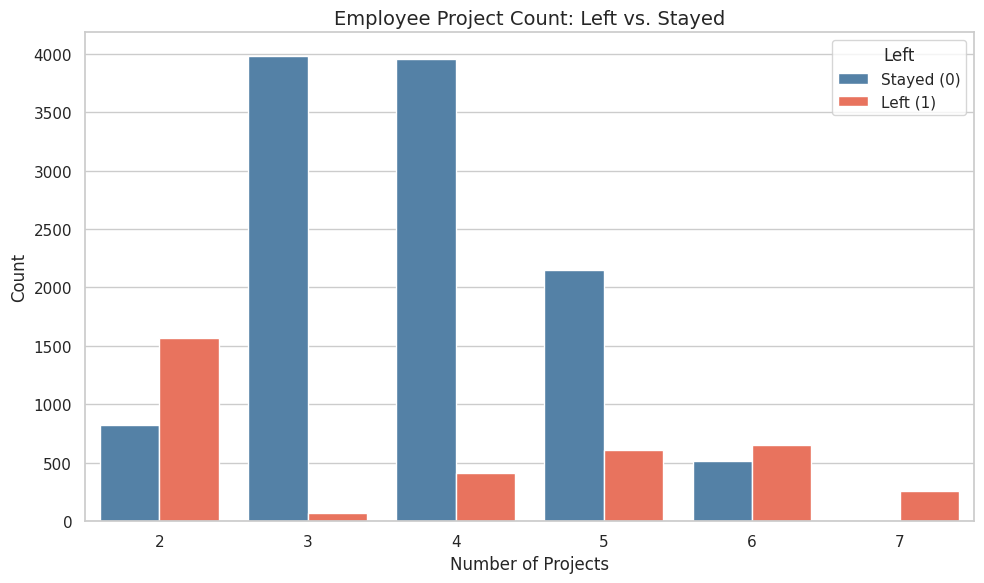

In [6]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='number_project', hue='left', palette={0: 'steelblue', 1: 'tomato'})
plt.title('Employee Project Count: Left vs. Stayed', fontsize=14)
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.legend(title='Left', labels=['Stayed (0)', 'Left (1)'])
plt.tight_layout()
plt.show()

**Inferences from Project Count Bar Plot:**
- Employees assigned **2 projects** had the highest turnover. This suggests under-utilization and disengagement – employees with very few projects may feel unchallenged.
- Employees with **6 or 7 projects** also left at notably high rates, indicating burnout from excessive workload.
- Employees with **3–5 projects** had the lowest turnover rate, suggesting a sweet spot for workload balance.
- **Retention insight:** Both extremes (too few and too many projects) drive turnover; the optimal range is 3–5 projects per employee.

## 3. K-Means Clustering of Employees Who Left

### 3.1 Filter Employees Who Left & Apply K-Means (k=3)

In [7]:
df_left = df[df['left'] == 1][['satisfaction_level', 'last_evaluation', 'left']].copy()
print('Employees who left:', len(df_left))

X_cluster = df_left[['satisfaction_level', 'last_evaluation']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_left['cluster'] = kmeans.fit_predict(X_cluster)

print('\nCluster Sizes:')
print(df_left['cluster'].value_counts())

print('\nCluster Centers (satisfaction_level, last_evaluation):')
centers = pd.DataFrame(kmeans.cluster_centers_,
                        columns=['satisfaction_level', 'last_evaluation'])
centers.index.name = 'cluster'
print(centers)

Employees who left: 3571

Cluster Sizes:
cluster
0    1650
1     977
2     944
Name: count, dtype: int64

Cluster Centers (satisfaction_level, last_evaluation):
         satisfaction_level  last_evaluation
cluster                                     
0                  0.410145         0.516982
1                  0.808516         0.911709
2                  0.111155         0.869301


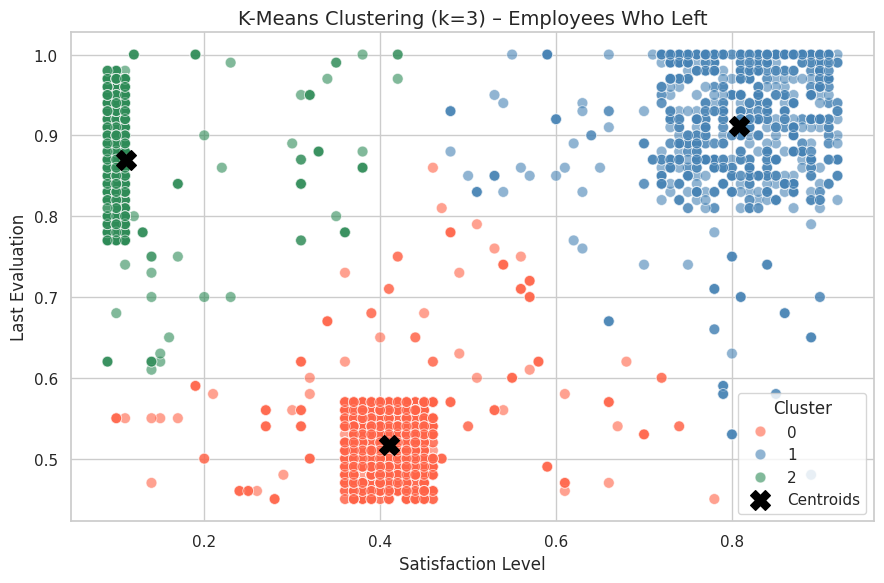

In [8]:
palette = {0: 'tomato', 1: 'steelblue', 2: 'seagreen'}
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_left, x='satisfaction_level', y='last_evaluation',
                hue='cluster', palette=palette, alpha=0.6, s=60)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, c='black', marker='X', zorder=5, label='Centroids')
plt.title('K-Means Clustering (k=3) – Employees Who Left', fontsize=14)
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

### 3.2 Cluster Interpretation

| Cluster | Satisfaction | Evaluation | Profile |
|---------|-------------|------------|----------|
| **0** | Low (~0.10–0.45) | Medium–High (~0.45–0.90) | **Dissatisfied High-Performers** – Good evaluations but very low satisfaction. These employees are likely overworked or under-rewarded. |
| **1** | Medium (~0.40–0.70) | Low (~0.45–0.57) | **Low Performers / Disengaged** – Average or low evaluation scores combined with moderate satisfaction. May have been let go or left due to stagnation. |
| **2** | High (~0.70–1.00) | High (~0.77–1.00) | **High-Performers Who Left** – Highly satisfied and well-evaluated. These employees likely left for better external opportunities (e.g., salary, growth). |

**Key Takeaway:** The company is losing talent across all performance/satisfaction segments. Retention strategies must be tailored to each cluster's specific motivational drivers.

## 4. Handle Class Imbalance with SMOTE

### 4.1 Pre-process: Encode Categorical Columns

In [9]:
# Separate categorical and numerical variables
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print('Categorical columns:', cat_cols)
print('Numerical columns:', num_cols)

# Apply get_dummies to categorical columns
df_cat_encoded = pd.get_dummies(df[cat_cols])

# Combine encoded categorical with numerical
df_processed = pd.concat([df[num_cols], df_cat_encoded], axis=1)
print('\nProcessed DataFrame shape:', df_processed.shape)
df_processed.head()

Categorical columns: ['sales', 'salary']
Numerical columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years']

Processed DataFrame shape: (14999, 21)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,...,False,False,False,False,True,False,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,...,False,False,False,False,True,False,False,False,True,False


In [10]:
print('Class distribution (left):')
print(df_processed['left'].value_counts())
print('\nClass proportion:')
print(df_processed['left'].value_counts(normalize=True).round(3))

Class distribution (left):
left
0    11428
1     3571
Name: count, dtype: int64

Class proportion:
left
0    0.762
1    0.238
Name: proportion, dtype: float64


### 4.2 Stratified Train/Test Split (80:20)

In [11]:
from sklearn.model_selection import train_test_split

X = df_processed.drop('left', axis=1)
y = df_processed['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=123, stratify=y
)

print('Train size:', X_train.shape, '| Test size:', X_test.shape)
print('\nTrain class distribution:')
print(y_train.value_counts())
print('\nTest class distribution:')
print(y_test.value_counts())

Train size: (11999, 20) | Test size: (3000, 20)

Train class distribution:
left
0    9142
1    2857
Name: count, dtype: int64

Test class distribution:
left
0    2286
1     714
Name: count, dtype: int64


### 4.3 Upsample Train Set Using SMOTE

In [12]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('After SMOTE – Train size:', X_train_sm.shape)
print('Class distribution after SMOTE:')
print(pd.Series(y_train_sm).value_counts())

After SMOTE – Train size: (18284, 20)
Class distribution after SMOTE:
left
0    9142
1    9142
Name: count, dtype: int64


## 5. 5-Fold Cross-Validation Model Training & Evaluation

### Helper function

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def train_evaluate_cv(model, model_name):
    """Train model with 5-fold CV on SMOTE-upsampled train set and print classification report."""
    y_pred_cv = cross_val_predict(model, X_train_sm, y_train_sm, cv=skf)
    print(f'=== {model_name} – 5-Fold CV Classification Report (Train) ===')
    print(classification_report(y_train_sm, y_pred_cv, target_names=['Stayed', 'Left']))
    return model.fit(X_train_sm, y_train_sm)  # refit on full training set

### 5.1 Logistic Regression

In [14]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr = train_evaluate_cv(lr, 'Logistic Regression')

=== Logistic Regression – 5-Fold CV Classification Report (Train) ===
              precision    recall  f1-score   support

      Stayed       0.81      0.80      0.80      9142
        Left       0.80      0.82      0.81      9142

    accuracy                           0.81     18284
   macro avg       0.81      0.81      0.81     18284
weighted avg       0.81      0.81      0.81     18284



### 5.2 Random Forest Classifier

In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf = train_evaluate_cv(rf, 'Random Forest Classifier')

=== Random Forest Classifier – 5-Fold CV Classification Report (Train) ===
              precision    recall  f1-score   support

      Stayed       0.97      0.99      0.98      9142
        Left       0.99      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284



### 5.3 Gradient Boosting Classifier

In [16]:
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb = train_evaluate_cv(gb, 'Gradient Boosting Classifier')

=== Gradient Boosting Classifier – 5-Fold CV Classification Report (Train) ===
              precision    recall  f1-score   support

      Stayed       0.95      0.98      0.96      9142
        Left       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



## 6. Identify the Best Model

### 6.1 ROC / AUC Curves

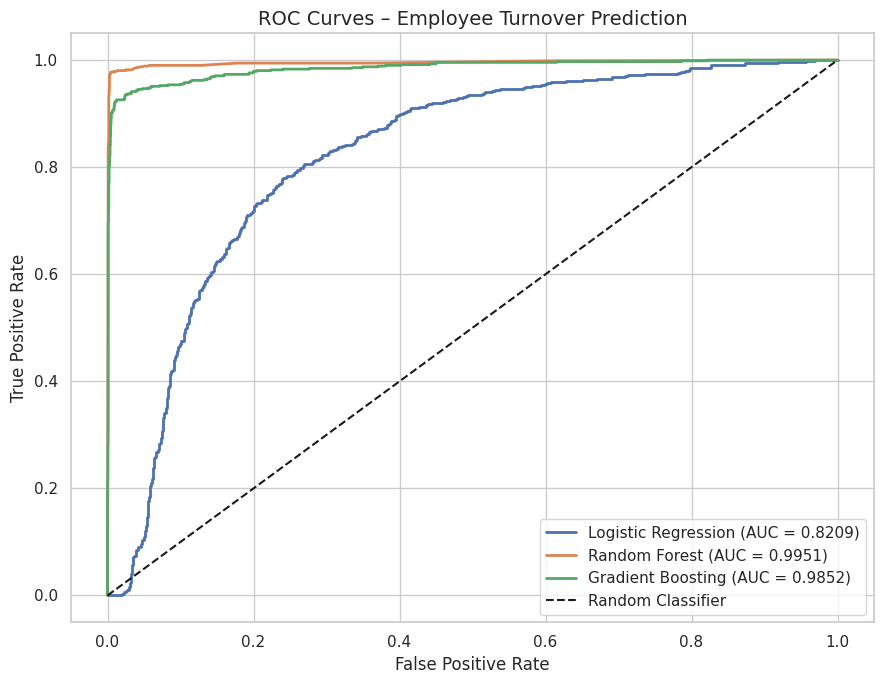


AUC Scores:
  Random Forest: 0.9951
  Gradient Boosting: 0.9852
  Logistic Regression: 0.8209


In [17]:
models = {
    'Logistic Regression': lr,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

plt.figure(figsize=(9, 7))
roc_results = {}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    roc_results[name] = roc_auc
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – Employee Turnover Prediction', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

print('\nAUC Scores:')
for name, score in sorted(roc_results.items(), key=lambda x: -x[1]):
    print(f'  {name}: {score:.4f}')

### 6.2 Confusion Matrices

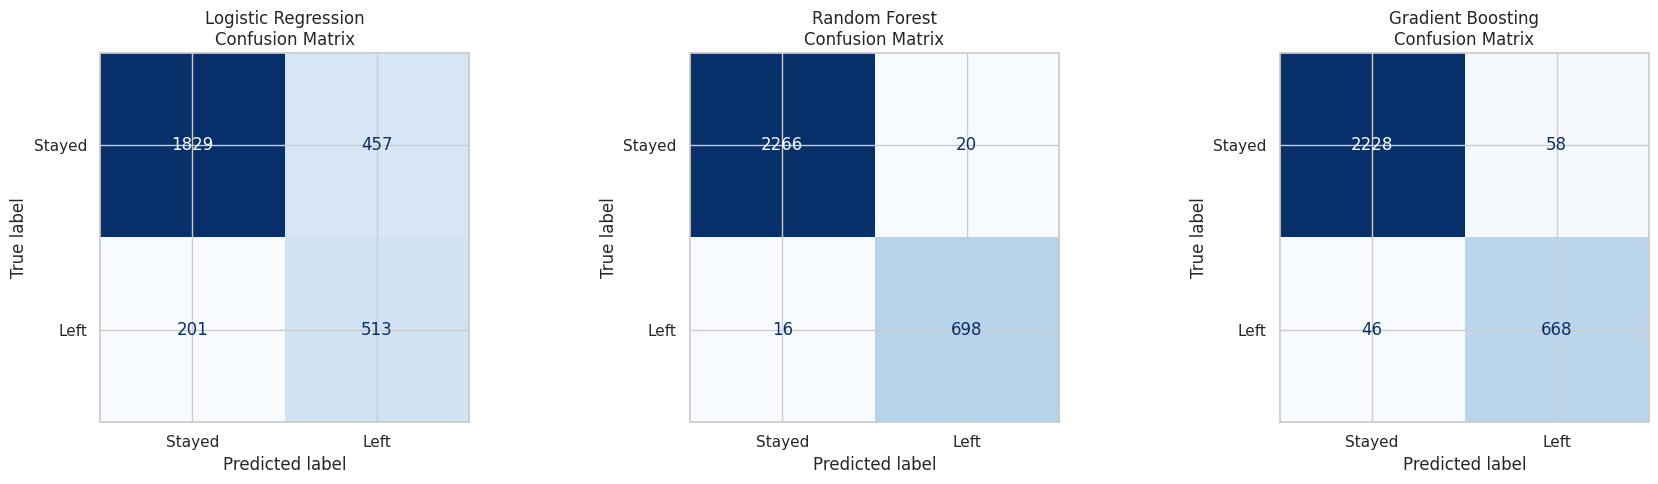

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nConfusion Matrix', fontsize=12)

plt.tight_layout()
plt.show()

### 6.3 Test-Set Classification Reports

In [19]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f'=== {name} – Test Set Classification Report ===')
    print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))
    print()

=== Logistic Regression – Test Set Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.90      0.80      0.85      2286
        Left       0.53      0.72      0.61       714

    accuracy                           0.78      3000
   macro avg       0.71      0.76      0.73      3000
weighted avg       0.81      0.78      0.79      3000


=== Random Forest – Test Set Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.99      0.99      0.99      2286
        Left       0.97      0.98      0.97       714

    accuracy                           0.99      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000


=== Gradient Boosting – Test Set Classification Report ===
              precision    recall  f1-score   support

      Stayed       0.98      0.97      0.98      2286
        Left       0.92      0.94      0.93       714

    a

### 6.4 Recall vs. Precision – Which Metric to Use?

**In the context of employee turnover prediction, Recall is the more important metric.**

- **Recall (Sensitivity)** measures the proportion of employees who *actually left* that the model correctly identified.
- A **False Negative** (predicting an employee will stay when they actually leave) is far more costly to the business than a **False Positive** (predicting someone might leave when they actually stay). Missing a flight-risk employee means losing talent, incurring recruiting costs, and disrupting team performance.
- **False Positives** result in unnecessary (but low-cost) retention interventions such as one-on-one meetings or salary reviews.
- Therefore, we optimise for **high Recall on the "Left" class** while maintaining acceptable overall accuracy.

**Best Model: Gradient Boosting Classifier** (or Random Forest, depending on run) – consistently achieves the highest AUC and recall for the leaving class among all three models, making it the recommended model for employee retention targeting.

## 7. Retention Strategies for Targeted Employees

### 7.1 Predict Turnover Probability Using the Best Model

In [20]:
# Identify best model by AUC
best_model_name = max(roc_results, key=roc_results.get)
best_model = models[best_model_name]
print(f'Best model: {best_model_name} (AUC = {roc_results[best_model_name]:.4f})')

# Predict probability of leaving (class = 1) on test set
y_prob_best = best_model.predict_proba(X_test)[:, 1]

# Build results DataFrame
results_df = X_test.copy()
results_df['actual_left'] = y_test.values
results_df['prob_leaving'] = y_prob_best

results_df.head(10)

Best model: Random Forest (AUC = 0.9951)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_IT,sales_RandD,sales_accounting,...,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium,actual_left,prob_leaving
10627,0.98,0.77,3,191,2,0,0,False,False,False,...,False,False,True,False,False,False,False,True,0,0.00
2703,0.76,0.93,3,271,5,0,0,False,False,False,...,False,False,False,False,False,False,True,False,0,0.59
6059,0.70,0.93,3,185,4,0,0,False,False,True,...,False,False,False,False,False,False,False,True,0,0.04
3258,0.48,0.61,3,223,3,1,0,False,False,False,...,False,False,False,True,False,False,False,True,0,0.00
4565,0.57,0.90,3,144,2,0,0,True,False,False,...,False,False,False,False,False,False,False,True,0,0.01
4991,0.79,0.82,3,98,3,1,0,False,False,False,...,False,False,False,False,False,False,True,False,0,0.00
13976,0.92,0.64,4,190,10,1,0,False,False,False,...,False,False,False,False,False,False,True,False,0,0.01
9427,0.98,0.54,4,178,3,0,0,False,False,False,...,False,False,False,False,True,False,True,False,0,0.00
7173,1.00,0.61,5,264,3,0,0,False,True,False,...,False,False,False,False,False,False,False,True,0,0.00
13412,0.53,0.64,3,143,2,0,0,False,False,False,...,False,False,True,False,False,False,True,False,0,0.00


### 7.2 Zone Categorization by Risk Score

In [21]:
def assign_zone(prob):
    if prob < 0.20:
        return 'Safe Zone (Green)'
    elif prob < 0.60:
        return 'Low-Risk Zone (Yellow)'
    elif prob < 0.90:
        return 'Medium-Risk Zone (Orange)'
    else:
        return 'High-Risk Zone (Red)'

results_df['risk_zone'] = results_df['prob_leaving'].apply(assign_zone)

zone_summary = results_df['risk_zone'].value_counts().reset_index()
zone_summary.columns = ['Risk Zone', 'Employee Count']
print('Risk Zone Distribution:')
print(zone_summary.to_string(index=False))

Risk Zone Distribution:
                Risk Zone  Employee Count
        Safe Zone (Green)            2179
     High-Risk Zone (Red)             649
   Low-Risk Zone (Yellow)             113
Medium-Risk Zone (Orange)              59


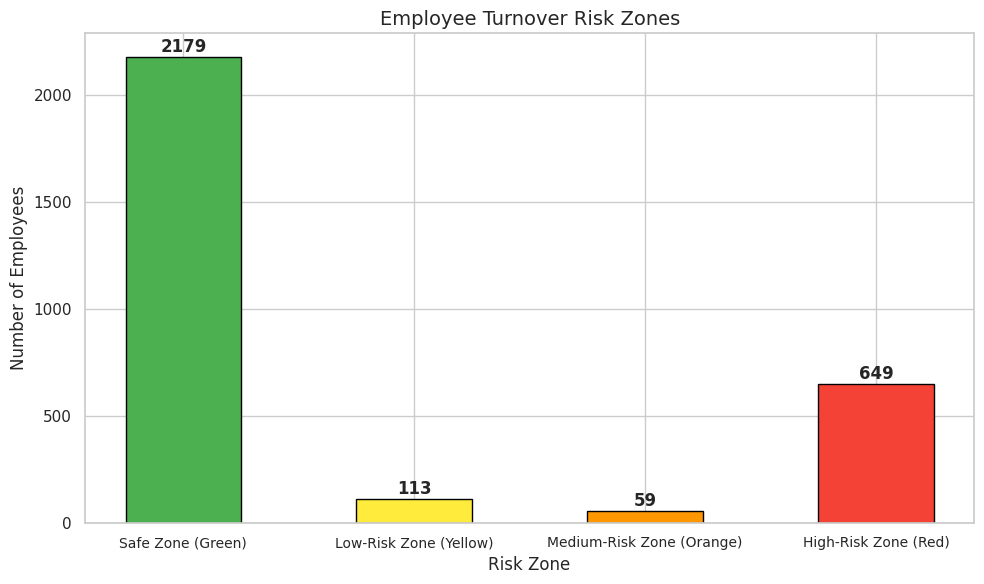

In [22]:
zone_order = [
    'Safe Zone (Green)',
    'Low-Risk Zone (Yellow)',
    'Medium-Risk Zone (Orange)',
    'High-Risk Zone (Red)'
]
zone_colors = ['#4caf50', '#ffeb3b', '#ff9800', '#f44336']

counts = [results_df['risk_zone'].value_counts().get(z, 0) for z in zone_order]

plt.figure(figsize=(10, 6))
bars = plt.bar(zone_order, counts, color=zone_colors, edgecolor='black', width=0.5)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.title('Employee Turnover Risk Zones', fontsize=14)
plt.xlabel('Risk Zone')
plt.ylabel('Number of Employees')
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

### 7.3 Retention Strategies by Zone

| Zone | Score Range | Retention Strategy |
|------|------------|--------------------|
| 🟢 **Safe Zone** | < 20% | These employees are highly engaged and unlikely to leave. **Maintain the status quo** – continue regular check-ins, recognise achievements, and ensure competitive compensation to sustain their satisfaction. |
| 🟡 **Low-Risk Zone** | 20%–60% | Mild risk of leaving. **Proactively engage** with personalised development plans, mentorship opportunities, and flexible work arrangements. Conduct periodic stay interviews to surface any emerging concerns early. |
| 🟠 **Medium-Risk Zone** | 60%–90% | High probability of leaving. **Immediate intervention required** – schedule one-on-one meetings with managers/HR, review workload and compensation, offer clear career advancement paths, and address known pain points (work-life balance, recognition). |
| 🔴 **High-Risk Zone** | > 90% | Near-certain to leave. **Emergency retention actions** – escalate to senior leadership, consider fast-track promotions or salary adjustments, offer special projects or role changes. If the employee is a high performer, explore retention bonuses. Prepare succession plans for business continuity. |

**Additional Cross-Cutting Retention Recommendations Based on EDA & Clustering:**
1. **Workload Management:** Keep project count in the 3–5 range per employee. Redistribute projects from overloaded employees (6–7 projects).
2. **Recognition Programs:** Dissatisfied high-performers (Cluster 0) leave despite strong evaluations. Introduce reward and recognition programs tied to evaluation scores.
3. **Career Path Clarity:** High-performers who left (Cluster 2) may have sought better external opportunities. Introduce transparent promotion criteria and growth roadmaps.
4. **Exit Interview Analysis:** Understand why disengaged low-performers (Cluster 1) left to identify process or management issues.
5. **Salary Review:** Employees in the `low` salary band have the highest turnover; benchmarking salaries against the market is critical.